<a href="https://colab.research.google.com/github/NehaSusan14/6THSEM-ML-LAB/blob/main/1BM23CS210_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your CSV file:


Saving iris (1).csv to iris (1).csv
User uploaded file "iris (1).csv" with length 4617 bytes

First 5 rows of your uploaded data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Features (X) shape: (150, 4)
Target (y) shape: (150,)

Accuracy Score: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]] 



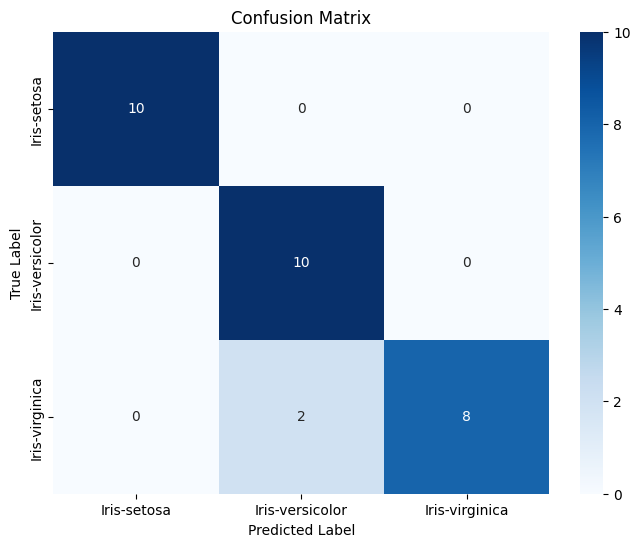

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import io

# 1. Upload your CSV file
print("Please upload your CSV file:")
uploaded = files.upload()

# Assuming you upload one file, get its name
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows to help identify columns
print("\nFirst 5 rows of your uploaded data:")
display(df.head())

# --- IMPORTANT: Adjust X and y based on your CSV file ---
# The code below assumes the last column is the target (y) and the rest are features (X).
# If your target column is different, please modify these lines.

# Example if your target column is named 'target_column_name':
# X = df.drop(columns=['target_column_name'])
# y = df['target_column_name']

# Example if your target column is at a specific index (e.g., first column):
# X = df.iloc[:, 1:] # All columns from the second one onwards
# y = df.iloc[:, 0]  # The first column

# Current assumption: last column is target, others are features
X = df.iloc[:, :-1].values  # All columns except the last one as features
y = df.iloc[:, -1].values   # The last column as the target

# If target values are not numerical, you might need to encode them (e.g., using LabelEncoder)
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)
# target_names = le.classes_ # Get original class names for plotting

# Determine target names for plotting (if y is numerical, these will be string representations)
target_names = [str(name) for name in sorted(np.unique(y))]


print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# 2. Split data into 80% training and 20% testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling (important for distance-based algorithms like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Choose an appropriate k value
# A k value of 3 is chosen as it often performs well with many datasets and helps avoid ties in voting.
k = 3

# 5. Build and train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

# 6. Predict on the test set
y_pred = knn.predict(X_test_scaled)

# 7. Display Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}\n")

# 8. Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm, "\n")

# Optional: Plot the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 9. Display Classification Report
cr = classification_report(y_test, y_pred, target_names=target_names)
print("Classification Report:")
print(cr)

In [4]:
import pandas as pd
import io
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Upload File (Google Colab specific)
from google.colab import files
uploaded = files.upload()

# 2. Load the Dataset
# Change 'iris.csv' to match your uploaded filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# 3. Preprocess Data
# Assuming the last column is the target and the rest are features
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Encode target if it is text (e.g., 'setosa' -> 0)
# If y is already numerical (0, 1, etc.), LabelEncoder will keep them as such in .classes_
# We convert them to strings for the classification_report
le = LabelEncoder()
y = le.fit_transform(y)

# 4. Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. Initialize and Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 6. Predict and Display Results
y_pred = knn.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


Saving diabetes.csv to diabetes (1).csv
Accuracy Score: 0.6494

Confusion Matrix:
[[65 34]
 [20 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.66      0.71        99
           1       0.51      0.64      0.56        55

    accuracy                           0.65       154
   macro avg       0.64      0.65      0.64       154
weighted avg       0.67      0.65      0.66       154

